# Summary

Ce Notebook présente une étude sur l'humidité relative nocturne durant la période estivale. L'objectif est d'étudier l'impact du changement climatique sur le taux d'humidité impactant l'acceptabilité des populations aux fortes chaleurs. 

La première section du Notebook se focalise sur les méthodes de sélection des valeurs. La première méthode se base sur la nuit astronomique (coucher-lever du soleil). Cette méthode sélectionne ainsi les valeurs nocturnes quelque soit la période de l'année, évitant l'influence de la rosée. La seconde méthode se base sur un choix fixé des heures définissant la nuit: 21h à 06h. Par la comparaison des valeurs, nous confirmons que la première méthode exclu les valeurs de rosée (notemment en aout) produisant des résultats plus sec. Nous notons le même comportement des valeurs au fil de l'été quelque soit la méthode. Pour se focaliser sur la période nocturne, nous sélections la première méthode afin de construire les normales.

Sur la période 2000-2024 nous observons un assèchemet estival global accentué en aout avec 5% d'humidité en moins par rapport à la période 1977-1999.

# Imports

In [1]:
import os
import pandas as pd

import packages.computing as cp

from packages.mining import open_data
from packages.plotting import plot_data, norm_compare

directory = os.chdir("/home/leopaul/Climate_Change_PO/")

In [2]:
sr = open_data(
    "data/FRNOR.RR2025010565429.PPDH.KEYuAAuu91dxAxu2BfU7xuA.csv",
    "U"
)

/home/leopaul/Climate_Change_PO/packages/mining.py:26: DtypeWarning: Columns (2,3,6,7,9,10,11,13,17,18,19,21,23,24,25,27,29,40,41,45,49,51,53,55,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=';', encoding='utf-8')


DatetimeIndex(['1930-08-01 00:00:00', '1930-08-01 03:00:00',
               '1930-08-01 06:00:00', '1930-08-01 09:00:00',
               '1930-08-01 12:00:00', '1930-08-01 15:00:00',
               '1930-08-01 21:00:00', '1930-08-02 00:00:00',
               '1930-08-02 03:00:00', '1930-08-02 06:00:00',
               ...
               '2025-06-28 03:00:00', '2025-06-28 06:00:00',
               '2025-06-28 09:00:00', '2025-06-28 12:00:00',
               '2025-06-28 15:00:00', '2025-06-28 18:00:00',
               '2025-06-28 21:00:00', '2025-06-29 00:00:00',
               '2025-06-29 03:00:00', '2025-06-29 06:00:00'],
              dtype='datetime64[ns]', name='DATE', length=46223, freq=None)


# Nuit astronomique

In [3]:
sr_stdy = sr.loc["1977-01-01 00:00:00":"2024-12-31 23:00:00"]
sr_astro_night = cp.night_time(sr_stdy, months=[6,7,8])
print(sr_astro_night)

night_date
1977-06-01    91.0
1977-06-02    92.0
1977-06-03    95.0
1977-06-04    53.0
1977-06-05    53.0
              ... 
2024-08-27    32.0
2024-08-28    64.0
2024-08-29    90.0
2024-08-30    90.0
2024-08-31    88.0
Name: value, Length: 4416, dtype: float64


# Nuit à horaire fixe

In [4]:
sr_stdy = sr.loc["1977-01-01":"2024-12-31"]
sr_fixed_night = cp.fixed_night_time(
    sr_stdy,
    [21,22,23,0,1,2,3,4,5,6],
    [6,7,8]
)
print(sr_fixed_night)

night_date
1977-06-01    95.50
1977-06-02    93.25
1977-06-03    93.75
1977-06-04    61.00
1977-06-05    58.75
              ...  
2024-08-27    45.50
2024-08-28    72.50
2024-08-29    93.00
2024-08-30    92.25
2024-08-31    88.50
Name: value, Length: 4416, dtype: float64


# Comparaisons

## Valeurs brutes

4.442831557469962
4.437912630546286
4.443834358862236


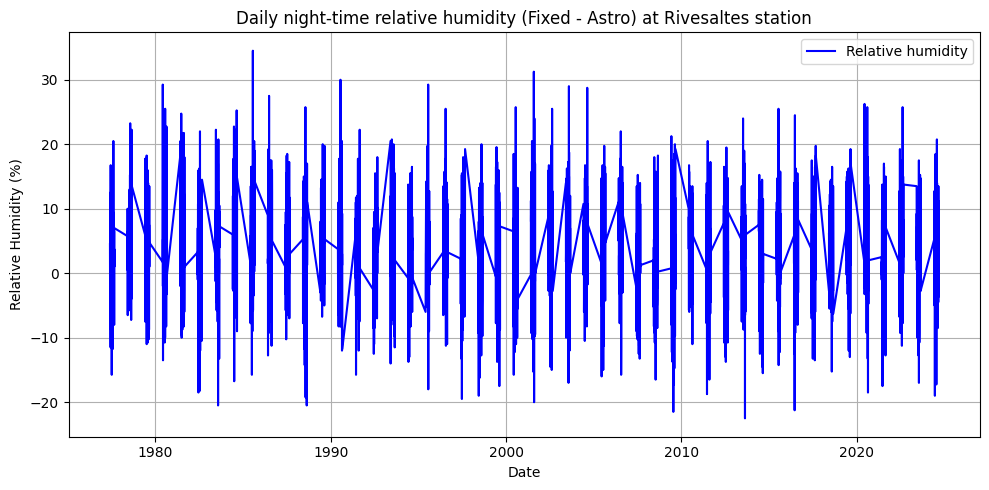

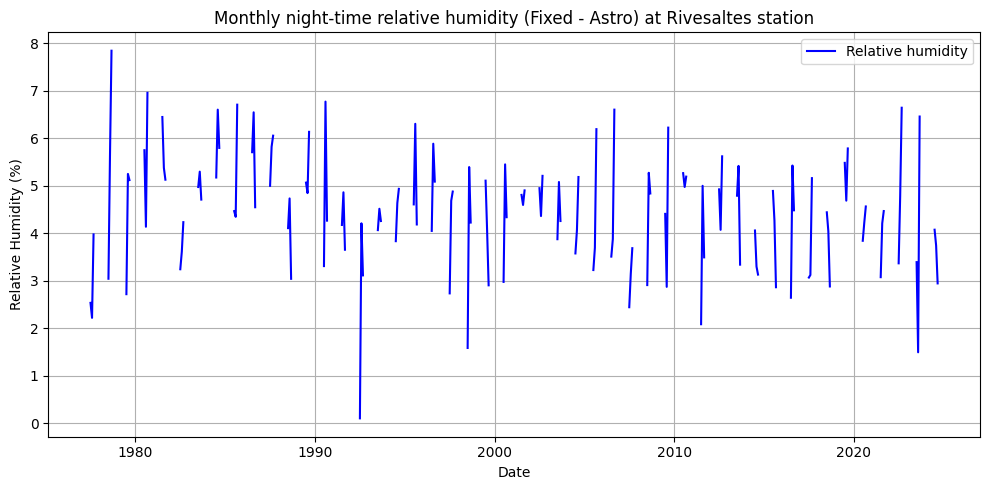

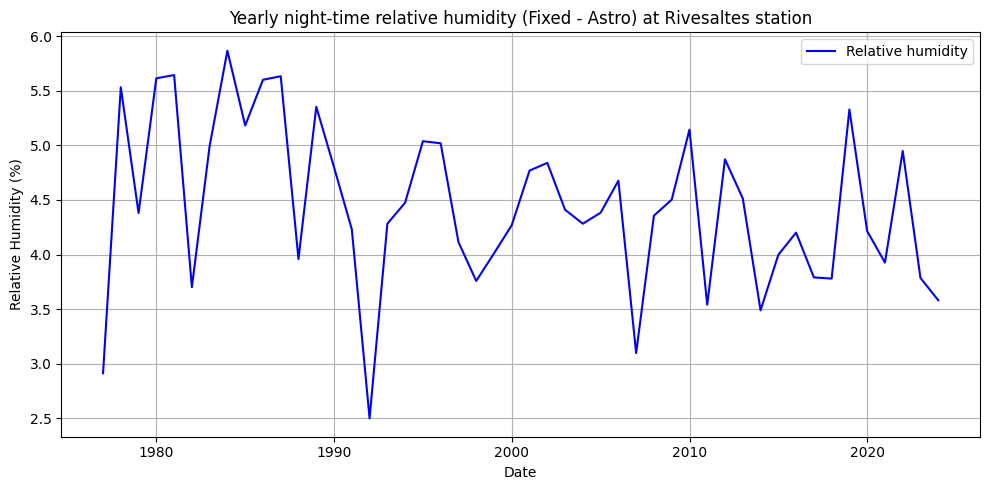

In [9]:
df = pd.concat(
    [sr_astro_night, sr_fixed_night], 
    axis=1,
    keys=["astro_night", "fixed_night"]
    )

df["Diff"] = df["fixed_night"] - df["astro_night"]
sr_diff = df["Diff"]

plot_data(
    sr_diff,
    "Relative humidity",
    "Daily night-time relative humidity (Fixed - Astro)",
    "humidity/daily_humidity",
    "JJA"
)
print(sr_diff.mean())

sr_m = sr_diff.resample("ME").mean()
plot_data(
    sr_m,
    "Relative humidity",
    "Monthly night-time relative humidity (Fixed - Astro)",
    "humidity/monthly_humidity",
    "JJA"
)
print(sr_m.mean())

sr_y = sr_diff.resample("YE", label="left").mean()
plot_data(
    sr_y,
    "Relative humidity",
    "Yearly night-time relative humidity (Fixed - Astro)",
    "humidity/yearly_humidity"
)
print(sr_y.mean())

## Normales

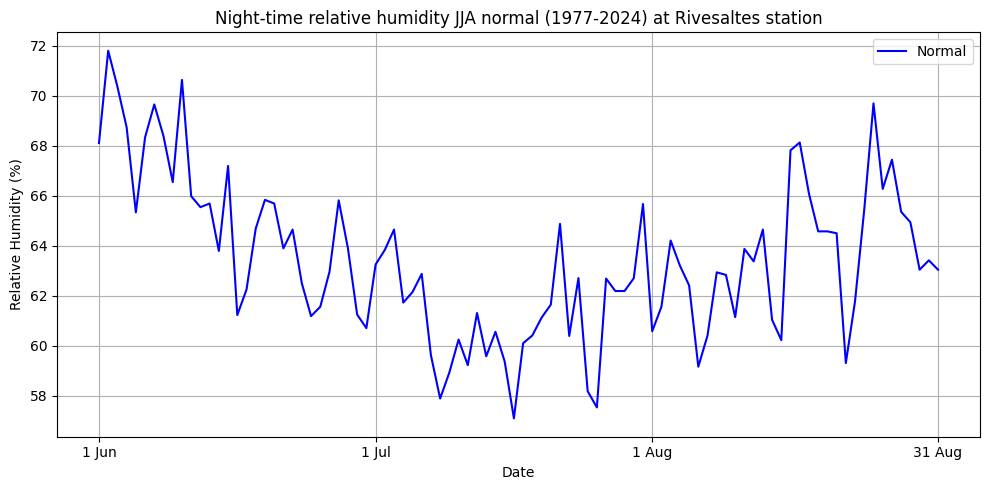

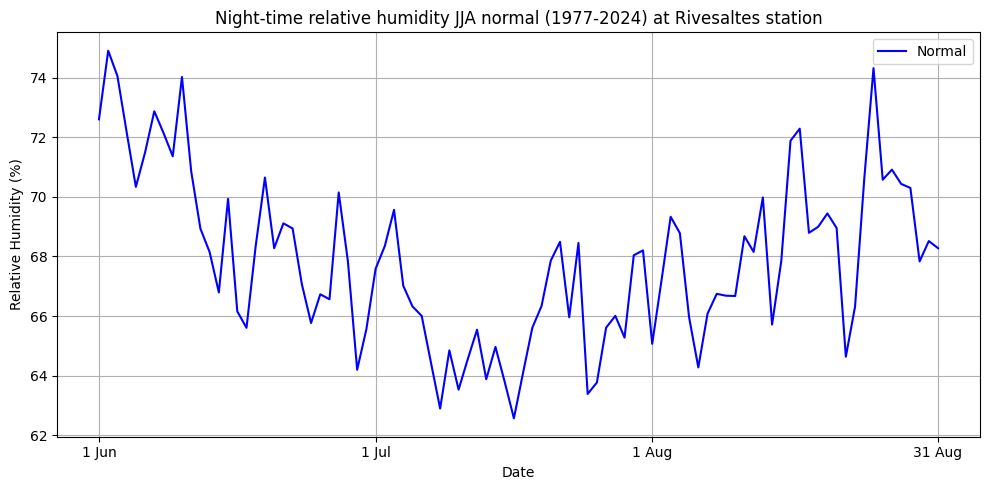

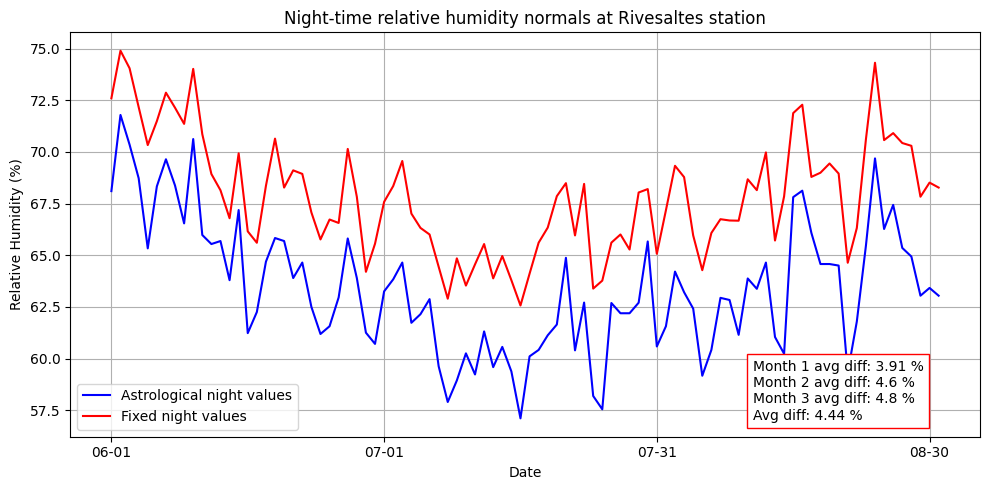

In [11]:
# Atronomical night-time normal
sr_astro_norm = cp.normal(
    sr_astro_night,
    "1977-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "Night-time relative humidity",
    "humidity",
    "JJA" 
)

# Fixed night-time normal
sr_fixed_norm = cp.normal(
    sr_fixed_night,
    "1977-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "Night-time relative humidity",
    "humidity",
    "JJA" 
)

norm_compare(
    sr_astro_norm,
    sr_fixed_norm,
    "Night-time relative humidity normals at Rivesaltes station",
    "Relative Humidity (%)",
    "Astrological night values",
    "Fixed night values",
    "%"
)

# Climatology

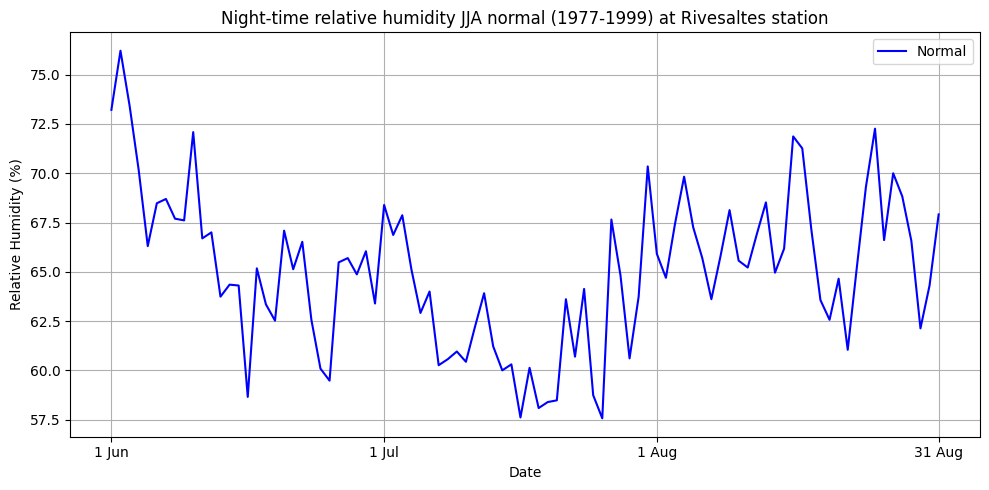

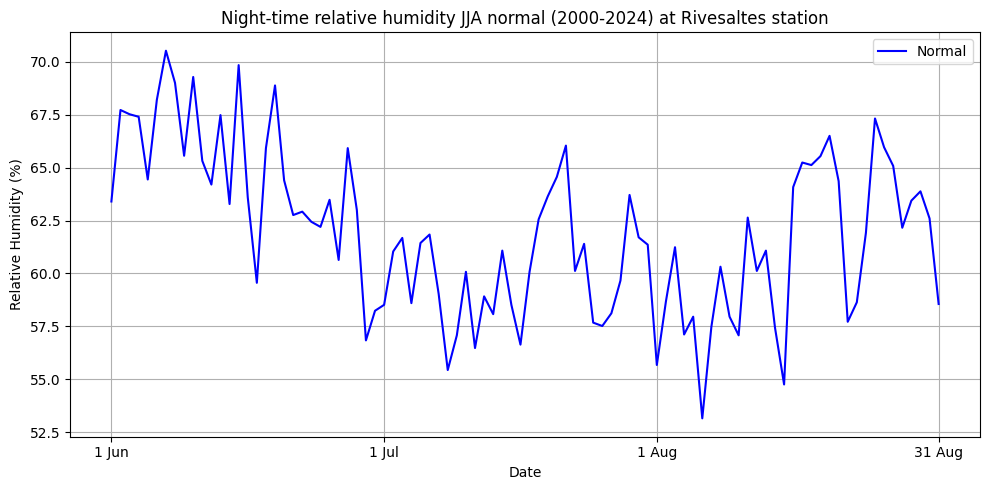

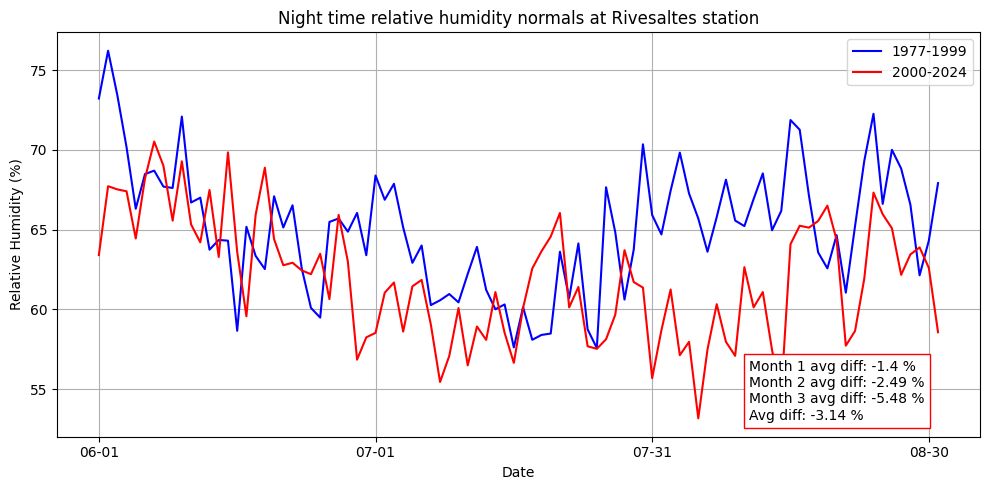

In [7]:
sr_norm_f = cp.normal(
    sr_astro_night,
    "1977-01-01 00:00:00",
    "1999-12-31 23:00:00",
    "Night-time relative humidity",
    "humidity",
    "JJA" 
)

sr_norm_s = cp.normal(
    sr_astro_night,
    "2000-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "Night-time relative humidity",
    "humidity",
    "JJA" 
)

norm_compare(
    sr_norm_f,
    sr_norm_s,
    "Night time relative humidity normals at Rivesaltes station",
    "Relative Humidity (%)",
    "1977-1999",
    "2000-2024",
    "%"
)